In [47]:
from __future__ import annotations

import pandas as pd 
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import os
import re
import torch

torch.distributions.Distribution.set_default_validate_args(False)

from sbi.inference import NPE
from sbi.neural_nets import posterior_nn

from sbi_for_diffusion_models.priors import build_prior_theta
from sbi_for_diffusion_models.mnpe import run_inference_npe
from sbi_for_diffusion_models.models.rt_choice_model import (
    max_num_pulses,
    pack_x_rt_choice,
    simulate_rt_choice_batch
)
from sbi_for_diffusion_models.data_simulator import simulate_training_sessions
from sbi_for_diffusion_models.models.rt_choice_model import max_num_pulses
from sbi_for_diffusion_models.Embeddings import PermutationInvariantEmbedding
from sbi_for_diffusion_models.run_config import RUN_CONFIG_PARAMS as cfg

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / "src"))

data = pd.read_csv("/Users/jamesfourie/Documents/Github/SBI-for-Diffusion-Models/marmoset_data.csv.gz", compression="gzip")

ayla_70_30 = data[(data["name"] == "Aayla") & (data["stage"] == "70-30")]
ayla_70_30 = ayla_70_30.reset_index(drop=True)

ayla_70_30

,name,specie,group,stage,sex,session_datetime,trial_datetime,trial,choice,outcome,rt,correct_side,flashes_left,flashes_right,numflashleft,numflashright,probflashleft,probflashright,flash_bins,init_time
0,Aayla,Marmoset,WT,70-30,F,17-Apr-2024-11-11-06,2024-04-17 11:11:33,5106,right,correct,5.243307,right,0000000100000000010000011010000000000000,1111111011111111101111100101111111111111,5,35,NaN,NaN,18.0,9.094804
1,Aayla,Marmoset,WT,70-30,F,17-Apr-2024-11-11-06,2024-04-17 11:11:43,5107,left,correct,6.587438,left,1101111111011101111111001100101001110111,0010000000100010000000110011010110001000,29,11,NaN,NaN,22.0,1.132043
2,Aayla,Marmoset,WT,70-30,F,17-Apr-2024-11-11-06,2024-04-17 11:11:54,5108,right,correct,6.011648,right,0010000100010000000011000110000000000101,1101111011101111111100111001111111111010,9,31,NaN,NaN,20.0,1.018770
3,Aayla,Marmoset,WT,70-30,F,17-Apr-2024-11-11-06,2024-04-17 11:12:06,5109,left,correct,2.331299,left,1010101110111011111001111111111111111011,0101010001000100000110000000000000000100,32,8,NaN,NaN,7.0,2.406875
4,Aayla,Marmoset,WT,70-30,F,17-Apr-2024-11-11-06,2024-04-17 11:12:12,5110,left,correct,1.514520,left,0111000010111101011011011101011111110101,1000111101000010100100100010100000001010,26,14,NaN,NaN,5.0,0.883297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1567,Aayla,Marmoset,WT,70-30,F,29-Apr-2024-09-41-38,2024-04-29 11:06:10,9568,left,correct,1.970423,left,1011011110111111011111010101011100111001,0100100001000000100000101010100011000110,28,12,NaN,NaN,6.0,1049.906083
1568,Aayla,Marmoset,WT,70-30,F,29-Apr-2024-09-41-38,2024-04-29 11:06:17,9569,left,correct,1.327014,left,1010110100101101111111001101101111111110,0101001011010010000000110010010000000001,28,12,NaN,NaN,4.0,1.145313
1569,Aayla,Marmoset,WT,70-30,F,29-Apr-2024-09-41-38,2024-04-29 11:06:24,9570,left,correct,2.823857,left,1110101000111011011110110110110101011010,0001010111000100100001001001001010100101,25,15,NaN,NaN,9.0,2.232715
1570,Aayla,Marmoset,WT,70-30,F,29-Apr-2024-09-41-38,2024-04-29 11:06:32,9571,right,correct,3.968353,right,0100000010011001100010010101000001100001,1011111101100110011101101010111110011110,13,27,NaN,NaN,13.0,2.392711


### Helper Functions

In [27]:
def _parse_bitstring_to_pulses(s: str, P: int) -> np.ndarray:
    """Parse a 0/1 pulse string into a length-P float array."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        bits = []
    else:
        bits = re.findall(r"[01]", str(s))

    arr = np.zeros(P, dtype=np.float32)
    n = min(P, len(bits))
    if n > 0:
        arr[:n] = np.asarray(bits[:n], dtype=np.float32)
    return arr


def flatten_observed_session(x_o: torch.Tensor, pulses_o: torch.Tensor) -> torch.Tensor:
    """Flatten one observed session to shape (1, T*(2+P))."""
    if x_o.ndim != 2 or pulses_o.ndim != 2:
        raise ValueError(f"x_o and pulses_o must be 2D, got {x_o.shape}, {pulses_o.shape}")
    if x_o.shape[0] != pulses_o.shape[0]:
        raise ValueError(f"x_o and pulses_o must have same number of trials, got {x_o.shape[0]} and {pulses_o.shape[0]}")

    session = torch.cat([x_o, pulses_o], dim=1)  # (T, 2+P)
    return session.reshape(1, -1)

def package_df_for_npe(
    df: pd.DataFrame,
    *,
    T: int,
    log_rt: bool,
    choice_col: str = "choice",
    rt_col: str = "rt",
    pulses_col: str = "flashes_right",
    device: str | torch.device = "cpu",
):
    """
    Convert a real dataframe into the flattened conditioning vector expected by NPE.

    Returns:
      x_o_flat: (1, T*(2+P)) float32 tensor
      (x_o, pulses_o): per-trial tensors for debugging
    """
    dev = torch.device(device)
    P = int(max_num_pulses())
    trial_dim = 2 + P

    rts = np.zeros(T, dtype=np.float32)
    choices = np.zeros(T, dtype=np.float32)
    pulses = np.zeros((T, P), dtype=np.float32)

    n = min(T, len(df))
    if n > 0:
        ch_series = df[choice_col].astype("string").str.strip().str.lower()

        is_right = ch_series.iloc[:n].eq("right").to_numpy()
        is_left = ch_series.iloc[:n].eq("left").to_numpy()

        ch = np.full(n, np.nan, dtype=np.float32)
        ch[is_right] = 1.0
        ch[is_left] = 0.0

        rt = pd.to_numeric(df[rt_col].iloc[:n], errors="coerce").astype(np.float32).to_numpy()

        # Fill invalid values with defaults since there is no mask channel anymore
        rts[:n] = np.where(np.isfinite(rt), rt, 1e-6)
        choices[:n] = np.where(np.isfinite(ch), ch, 0.0)

        pulse_strs = df[pulses_col].iloc[:n].to_numpy()
        for i in range(n):
            pulses[i] = _parse_bitstring_to_pulses(pulse_strs[i], P)

    rt_choice = torch.tensor(
        np.stack([rts, choices], axis=1),
        device=dev,
        dtype=torch.float32,
    )  # (T, 2)

    pulses_o = torch.tensor(
        pulses,
        device=dev,
        dtype=torch.float32,
    )  # (T, P)

    x_o = pack_x_rt_choice(rt_choice, log_rt=bool(log_rt)).view(T, 2)
    x_o_flat = flatten_observed_session(x_o, pulses_o)

    assert x_o_flat.shape == (1, T * trial_dim), (x_o_flat.shape, T, trial_dim)
    return x_o_flat, (x_o, pulses_o)


def load_npe(model_path: str, device: str = "cpu"):
    """
    Load a trained NPE density estimator and rebuild its architecture from the saved config.
    """
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    saved_cfg = checkpoint["config"]

    P = max_num_pulses()
    T = int(saved_cfg.NUM_TRIALS_OBS)
    trial_dim = 2 + P
    theta_dim = 5
    x_dim = T * trial_dim

    embedding_net = PermutationInvariantEmbedding(
        num_trials=T,
        trial_dim=trial_dim,
        trial_net_hidden=int(saved_cfg.NPE_TRIAL_NET_HIDDEN),
        trial_net_layers=int(saved_cfg.NPE_TRIAL_NET_LAYERS),
        trial_net_output_dim=int(saved_cfg.NPE_TRIAL_NET_OUTPUT_DIM),
        post_agg_hidden=int(saved_cfg.NPE_POST_AGG_HIDDEN),
        post_agg_layers=int(saved_cfg.NPE_POST_AGG_LAYERS),
        output_dim=int(saved_cfg.NPE_EMBEDDING_OUTPUT_DIM),
        aggregation=str(saved_cfg.NPE_AGG_FN),
    )

    est_builder = posterior_nn(
        model="nsf",
        z_score_theta="independent",
        z_score_x="none",
        hidden_features=int(saved_cfg.NPE_HIDDEN_FEATURES),
        num_transforms=int(saved_cfg.NPE_NUM_TRANSFORMS),
        num_bins=int(saved_cfg.NPE_NUM_BINS),
        embedding_net=embedding_net,
    )

    dummy_theta = torch.randn(2, theta_dim, device=device)
    dummy_x = torch.randn(2, x_dim, device=device)
    density_estimator = est_builder(dummy_theta, dummy_x)

    density_estimator.load_state_dict(checkpoint["state_dict"], strict=True)
    density_estimator.to(device)
    density_estimator.eval()
    return density_estimator, saved_cfg


def infer_from_real_df(df_real: pd.DataFrame, *, model_path: str, device: str = "cpu"):
    """
    Load a trained NPE model, package a real dataframe into the conditioning vector,
    and draw posterior samples.
    """
    dev = torch.device(device)

    density_estimator, saved_cfg = load_npe(model_path, device=device)

    prior_theta = build_prior_theta()
    if hasattr(prior_theta, "to"):
        prior_theta.to(dev)

    inference_obj = NPE(prior=prior_theta, device=device)

    T = int(saved_cfg.NUM_TRIALS_OBS)
    x_o_flat, debug = package_df_for_npe(
        df_real,
        T=T,
        log_rt=bool(saved_cfg.LOG_RT_MANUALLY),
        choice_col="choice",
        rt_col="rt",
        pulses_col="flashes_right",
        device=device,
    )
    x_o_flat = x_o_flat.to(dev, dtype=torch.float32)

    samples = run_inference_npe(saved_cfg, inference_obj, density_estimator, x_o_flat, prior_theta)
    return samples, x_o_flat, saved_cfg, debug


### Run df through pretrained model

In [28]:
MODEL_PATH = os.path.expanduser("/Users/jamesfourie/Documents/Github/SBI-for-Diffusion-Models/models/npe_rt_choice.pt")
device = "cuda" if torch.cuda.is_available() else "cpu"

samples, x_o_flat, saved_cfg, debug = infer_from_real_df(
    ayla_70_30,             
    model_path=MODEL_PATH,
    device=device,
)

print(samples.shape)      

  0%|          | 0/20000 [00:00<?, ?it/s]

torch.Size([20000, 5])


In [40]:
print("Shape:", samples.shape)

means = samples.mean(dim=0)
stds  = samples.std(dim=0)

for name, m, s in zip(["a0", "lam", "v", "B", "tau"], means, stds):
    print(f"{name:>4}: mean={m:.4f}, sd={s:.4f}")

Shape: torch.Size([20000, 5])
  a0: mean=0.4958, sd=0.1178
 lam: mean=0.4065, sd=0.1786
   v: mean=1.3894, sd=0.6660
   B: mean=4.6670, sd=2.0700
 tau: mean=0.5030, sd=0.2547


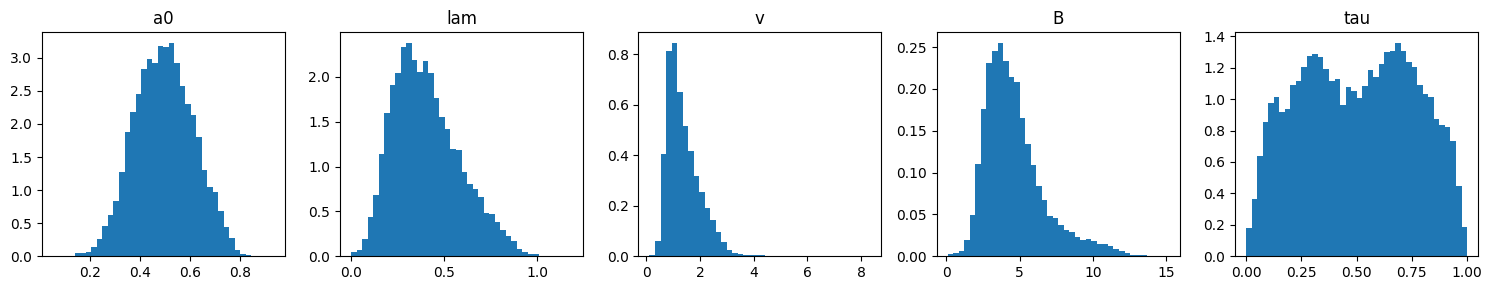

In [ ]:
names = ["a0", "lam", "v", "B", "tau"]

fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    axes[i].hist(samples[:, i].numpy(), bins=40, density=True)
    axes[i].set_title(names[i])

plt.tight_layout()
plt.show()

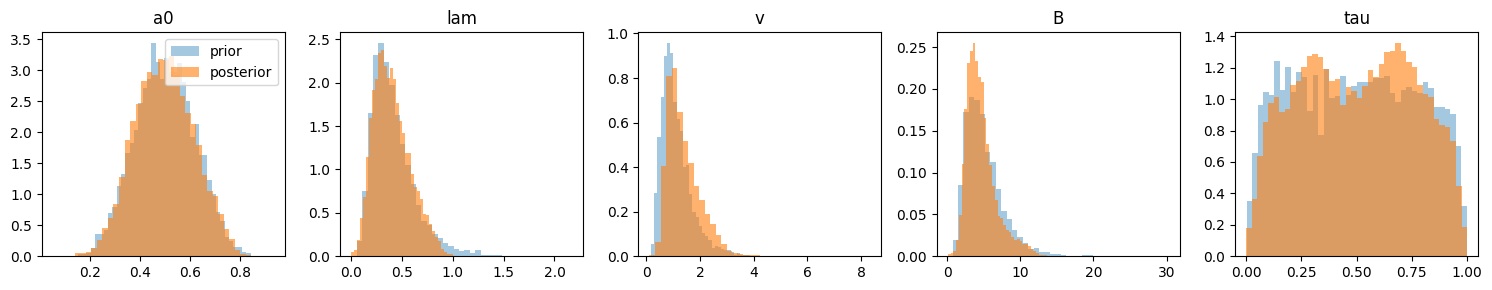

In [31]:
prior_theta = build_prior_theta()
prior_samples = prior_theta.sample((5000,)).cpu()

fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    axes[i].hist(prior_samples[:, i], bins=40, density=True, alpha=0.4, label="prior")
    axes[i].hist(samples[:, i], bins=40, density=True, alpha=0.6, label="posterior")
    axes[i].set_title(names[i])

axes[0].legend()
plt.tight_layout()
plt.show()

In [32]:
q = torch.quantile(samples, torch.tensor([0.05, 0.5, 0.95]), dim=0)

for i, name in enumerate(names):
    lo, med, hi = q[:, i]
    print(f"{name}: 5%={lo:.3f}, 50%={med:.3f}, 95%={hi:.3f}")

a0: 5%=0.308, 50%=0.494, 95%=0.696
lam: 5%=0.157, 50%=0.383, 95%=0.744
v: 5%=0.644, 50%=1.230, 95%=2.575
B: 5%=2.175, 50%=4.237, 95%=9.030
tau: 5%=0.099, 50%=0.509, 95%=0.905


In [ ]:
names = ["a0", "lam", "v", "B", "tau"]

post = samples.cpu()
prior = prior_theta.sample((post.shape[0],)).cpu()

post_mean, post_std = post.mean(0), post.std(0)
prior_mean, prior_std = prior.mean(0), prior.std(0)

print("param   post_std/prior_std   |mean shift| / prior_std")
for i, nm in enumerate(names):
    shrink = (post_std[i] / prior_std[i]).item()
    shift  = (torch.abs(post_mean[i] - prior_mean[i]) / prior_std[i]).item()
    print(f"{nm:>4}    {shrink:8.3f}             {shift:8.3f}")

param   post_std/prior_std   |mean shift| / prior_std
  a0       0.995                0.031
 lam       0.797                0.049
   v       1.089                0.421
   B       0.769                0.153
 tau       0.942                0.003


In [49]:
def unpack_flat_session(x_flat_1d: torch.Tensor, T: int, P: int):
    """
    x_flat_1d: shape (T*(2+P+1),)
    Returns rt, choice, mask as numpy arrays of length T (mask is 0/1)
    """
    trial_dim = 2 + P 
    x = x_flat_1d.view(T, trial_dim)
    rt = x[:, 0]
    choice = x[:, 1]
    mask = x[:, -1]
    return rt.detach().cpu().numpy(), choice.detach().cpu().numpy(), mask.detach().cpu().numpy()

def summarize_session(rt, choice, mask):
    m = mask > 0.5
    rt_m = rt[m]
    ch_m = choice[m]
    out = {}
    out["n"] = int(m.sum())
    out["p_right"] = float(np.mean(ch_m)) if out["n"] > 0 else np.nan
    out["rt_q10"] = float(np.quantile(rt_m, 0.10)) if out["n"] > 0 else np.nan
    out["rt_q50"] = float(np.quantile(rt_m, 0.50)) if out["n"] > 0 else np.nan
    out["rt_q90"] = float(np.quantile(rt_m, 0.90)) if out["n"] > 0 else np.nan
    return out, rt_m, ch_m

def run_ppc(
    samples: torch.Tensor,
    x_o_flat: torch.Tensor,
    prior_theta,
    saved_cfg,
    *,
    n_ppc: int = 100,
    device: str = "cpu",
):
    dev = torch.device(device)
    P = int(max_num_pulses())
    T = int(saved_cfg.NUM_TRIALS_OBS)

    # --- observed summary ---
    rt_obs, ch_obs, m_obs = unpack_flat_session(x_o_flat[0], T, P)
    obs_sum, rt_obs_m, ch_obs_m = summarize_session(rt_obs, ch_obs, m_obs)

    # --- pick posterior thetas ---
    n_ppc = min(n_ppc, samples.shape[0])
    thetas = samples[:n_ppc].to(dev)

    # --- simulate posterior predictive sessions ---
    _, x_sim = simulate_training_sessions(
        prior_theta=prior_theta,
        num_sessions=n_ppc,
        num_trials=T,
        device=dev,
        simulate_batch_fn=simulate_rt_choice_batch, 
        mu_sensory=float(saved_cfg.MU_SENSORY),
        p_success=float(saved_cfg.P_SUCCESS),
        P=P,
        log_rt=bool(saved_cfg.LOG_RT_MANUALLY),
        theta=thetas,
    )
    x_sim = x_sim.detach().cpu()

    sim_summaries = []
    rt_sims = []
    for i in range(n_ppc):
        rt_i, ch_i, m_i = unpack_flat_session(x_sim[i], T, P)
        s_i, rt_i_m, _ = summarize_session(rt_i, ch_i, m_i)
        sim_summaries.append(s_i)
        rt_sims.append(rt_i_m)

    # --- aggregate simulated summaries ---
    p_rights = np.array([s["p_right"] for s in sim_summaries], dtype=float)
    q10s = np.array([s["rt_q10"] for s in sim_summaries], dtype=float)
    q50s = np.array([s["rt_q50"] for s in sim_summaries], dtype=float)
    q90s = np.array([s["rt_q90"] for s in sim_summaries], dtype=float)

    # --- plots ---
    fig = plt.figure(figsize=(14, 4))

    # 1) choice rate distribution
    ax1 = plt.subplot(1, 3, 1)
    ax1.hist(p_rights[~np.isnan(p_rights)], bins=25, density=True, alpha=0.6)
    ax1.axvline(obs_sum["p_right"], linewidth=2)
    ax1.set_title("PPC: p(right)")
    ax1.set_xlabel("p(right)")
    ax1.set_ylabel("density")

    # 2) RT histogram overlay (observed vs predictive pooled)
    ax2 = plt.subplot(1, 3, 2)
    # pool RTs across PPC sims (cap to avoid huge arrays)
    pooled = np.concatenate(rt_sims)
    if pooled.size > 200000:
        pooled = np.random.choice(pooled, size=200000, replace=False)

    ax2.hist(pooled, bins=60, density=True, alpha=0.5, label="posterior predictive (pooled)")
    ax2.hist(rt_obs_m, bins=60, density=True, alpha=0.5, label="observed")
    ax2.set_title("PPC: RT distribution")
    ax2.set_xlabel("RT (same units as training)")
    ax2.set_ylabel("density")
    ax2.legend()

    # 3) RT quantiles check
    ax3 = plt.subplot(1, 3, 3)
    qs = [0.10, 0.50, 0.90]
    sim_q_means = [np.nanmean(q10s), np.nanmean(q50s), np.nanmean(q90s)]
    sim_q_los   = [np.nanquantile(q10s, 0.05), np.nanquantile(q50s, 0.05), np.nanquantile(q90s, 0.05)]
    sim_q_his   = [np.nanquantile(q10s, 0.95), np.nanquantile(q50s, 0.95), np.nanquantile(q90s, 0.95)]
    obs_qs      = [obs_sum["rt_q10"], obs_sum["rt_q50"], obs_sum["rt_q90"]]

    x = np.arange(3)
    ax3.errorbar(x, sim_q_means, yerr=[np.array(sim_q_means)-np.array(sim_q_los),
                                      np.array(sim_q_his)-np.array(sim_q_means)],
                 fmt="o", capsize=4, label="posterior predictive (mean ± 90% CI)")
    ax3.plot(x, obs_qs, "x", markersize=10, label="observed")
    ax3.set_xticks(x)
    ax3.set_xticklabels([f"q{int(100*q)}" for q in qs])
    ax3.set_title("PPC: RT quantiles")
    ax3.set_ylabel("RT")
    ax3.legend()

    plt.tight_layout()
    plt.show()

    print("Observed summary:", obs_sum)
    print("PPC p(right): mean±sd =", float(np.nanmean(p_rights)), float(np.nanstd(p_rights)))
    print("PPC RT q10/q50/q90 mean =", [float(np.nanmean(q10s)), float(np.nanmean(q50s)), float(np.nanmean(q90s))])

    return sim_summaries

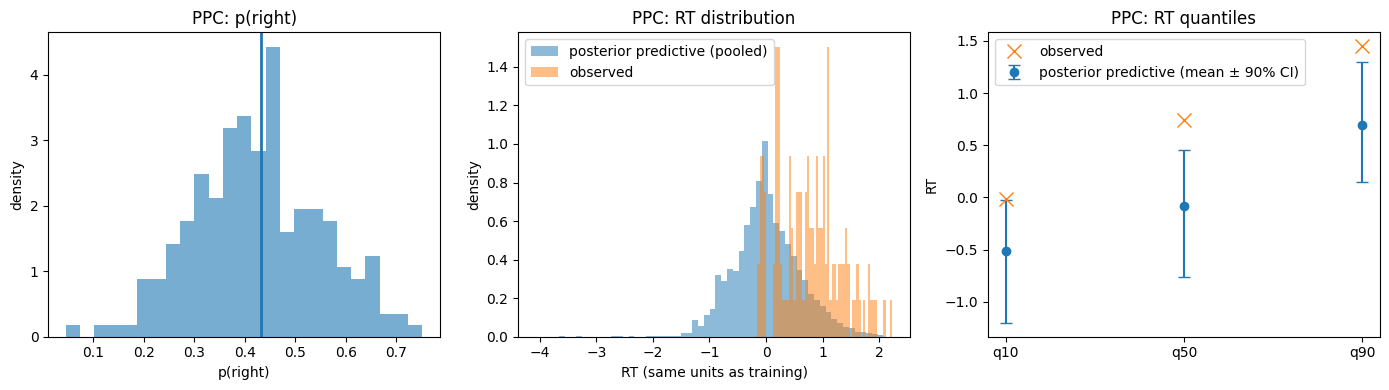

Observed summary: {'n': 134, 'p_right': 0.43283581733703613, 'rt_q10': -0.019842445850372314, 'rt_q50': 0.7449356317520142, 'rt_q90': 1.4495582580566406}
PPC p(right): mean±sd = 0.42462500769644973 0.126593069340262
PPC RT q10/q50/q90 mean = [-0.5150475648790598, -0.07967772930744105, 0.6923628892109264]


In [50]:
sim_summaries = run_ppc(
    samples=samples,
    x_o_flat=x_o_flat,
    prior_theta=prior_theta,
    saved_cfg=saved_cfg,
    n_ppc=200,   
    device=device,
)